# Quantitative comparison: RL VS NN (on test dataset)

2 Datasets:
- Blur + Poisson
- Full detector model

Analysing:
- PSNR
- SSIM
- MSE

Reporting:
- Distribution
- Mean
- Standard deviation
- Boxplots

In [1]:
import torch
from torch.utils.data import DataLoader
import pandas as pd

from src.data_helpers import GeometricDataGenerator
from src.plotting_helpers import plot_comparative_results
from src.testing_helpers import comparative_testing
from src.NNdeconvolution import DeconvolutionUNet_Baseline

In [2]:
BATCH_SIZE=32
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load best model
model = DeconvolutionUNet_Baseline()
state_dict = torch.load('models/nn_baseline_model.pth', map_location=torch.device(device))
model.load_state_dict(state_dict)
model.eval()

model_about_df = pd.read_csv('models/nn_baseline_model_about.csv')

  0%|          | 0/500 [00:00<?, ?it/s]

C:\Users\HP\miniconda3\envs\ml_env_new\Lib\site-packages\torchmetrics\utilities\prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


  0%|          | 0/500 [00:00<?, ?it/s]

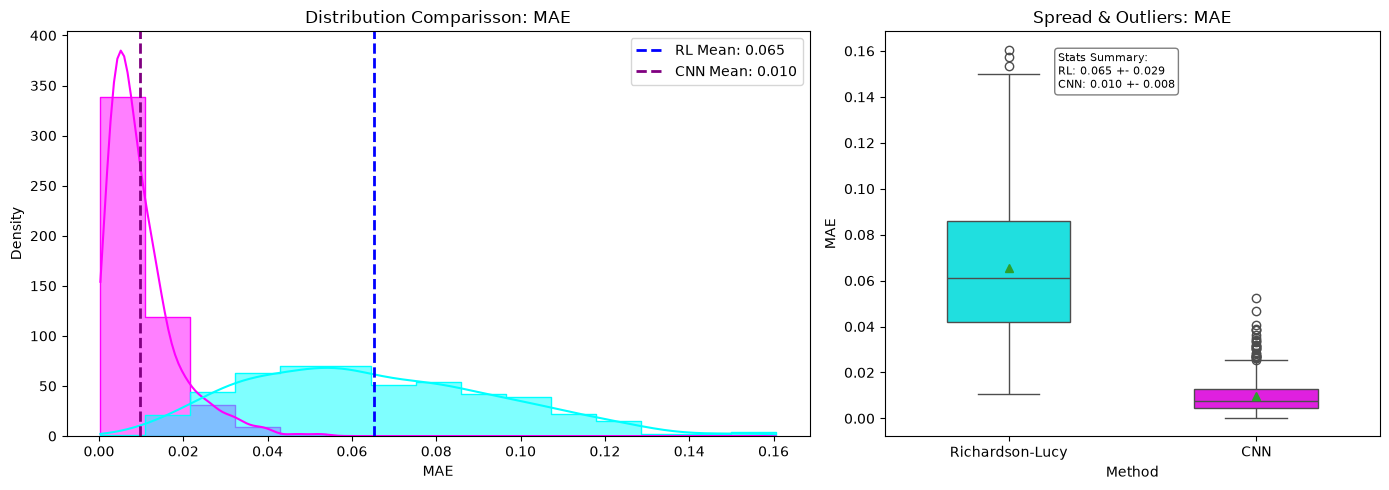

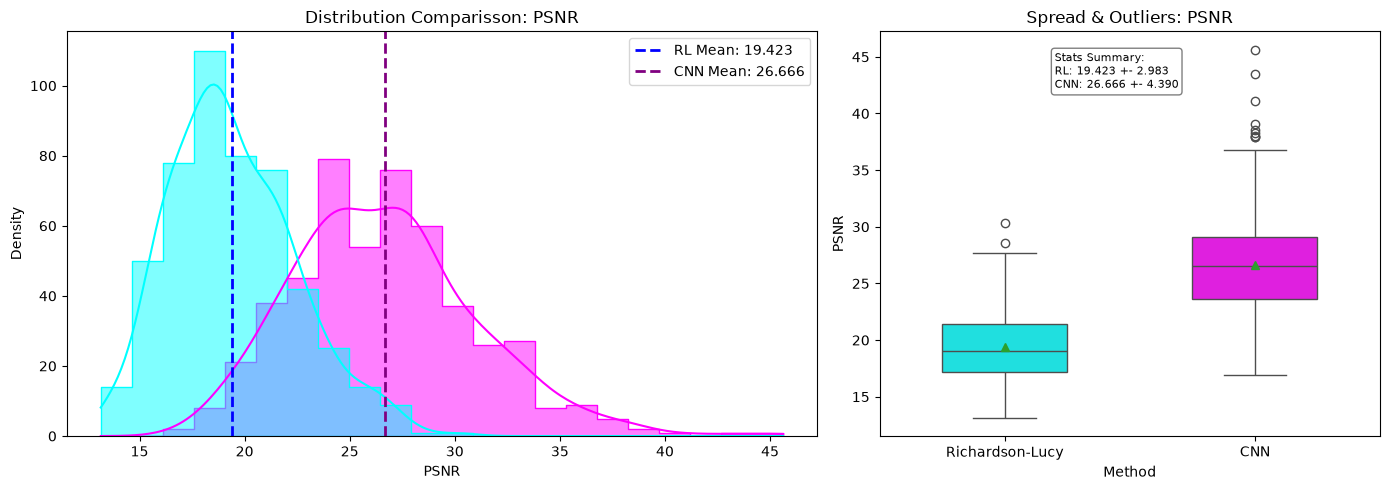

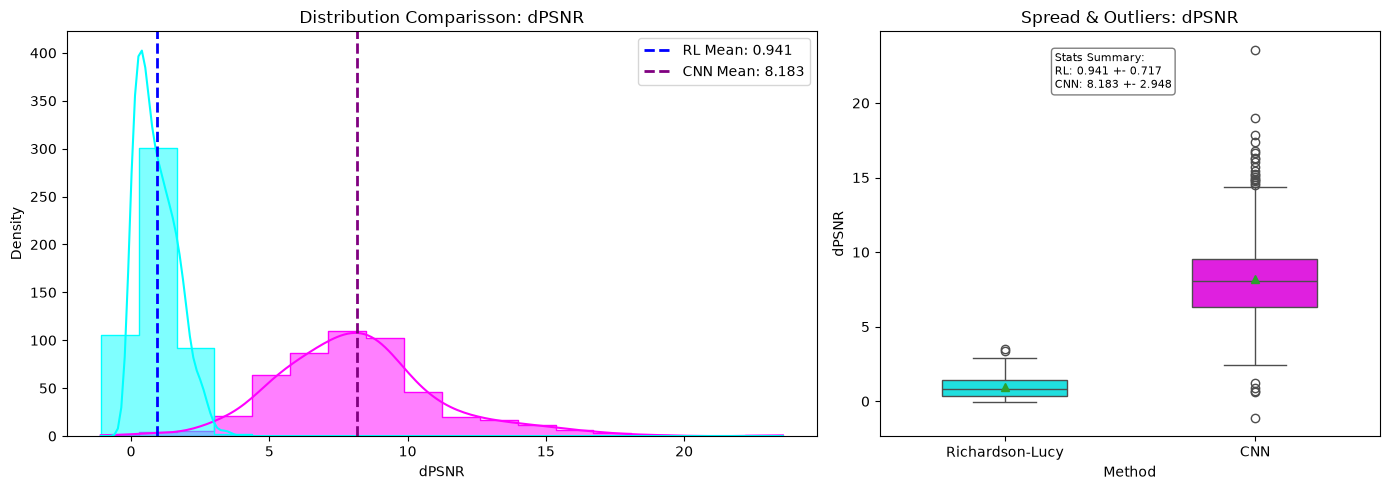

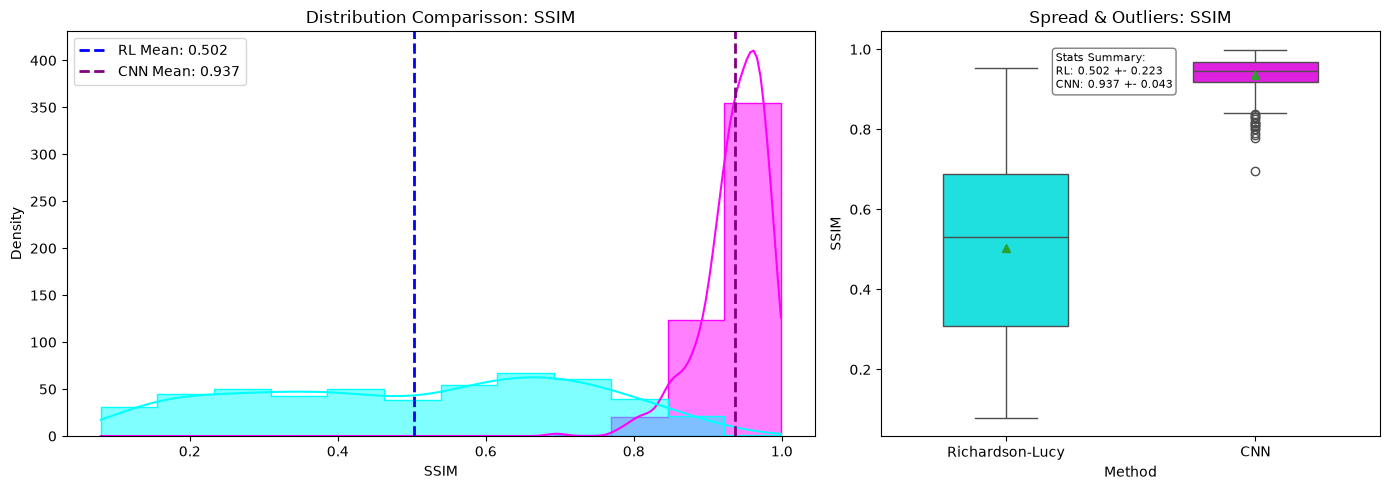

In [3]:
# Create blur + poisson noise dataset
test_dataset_blur = GeometricDataGenerator(
    num_samples=500,
    size=256,
    seed=42,
    poisson_noise=True,
    full_detector_model=False,
    data_loading=False
)

test_dataset_blur_dataloading = GeometricDataGenerator(
    num_samples=500,
    size=256,
    seed=42,
    poisson_noise=True,
    full_detector_model=False,
    data_loading=True
)
test_dataloader_blur = DataLoader(
    test_dataset_blur_dataloading,
    batch_size=1
)

df_blur = comparative_testing(
    dataset=test_dataset_blur,
    dataloader=test_dataloader_blur,
    model=model,
    model_about_df=model_about_df,
    device=device,
    path="comparison",
    filename="comparative_results_blur.csv"
)
plot_comparative_results(
    df=df_blur,
    path="comparison",
    save_name='comparative_results_blur'
)

  0%|          | 0/500 [00:00<?, ?it/s]

C:\Users\HP\miniconda3\envs\ml_env_new\Lib\site-packages\torchmetrics\utilities\prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


  0%|          | 0/500 [00:00<?, ?it/s]

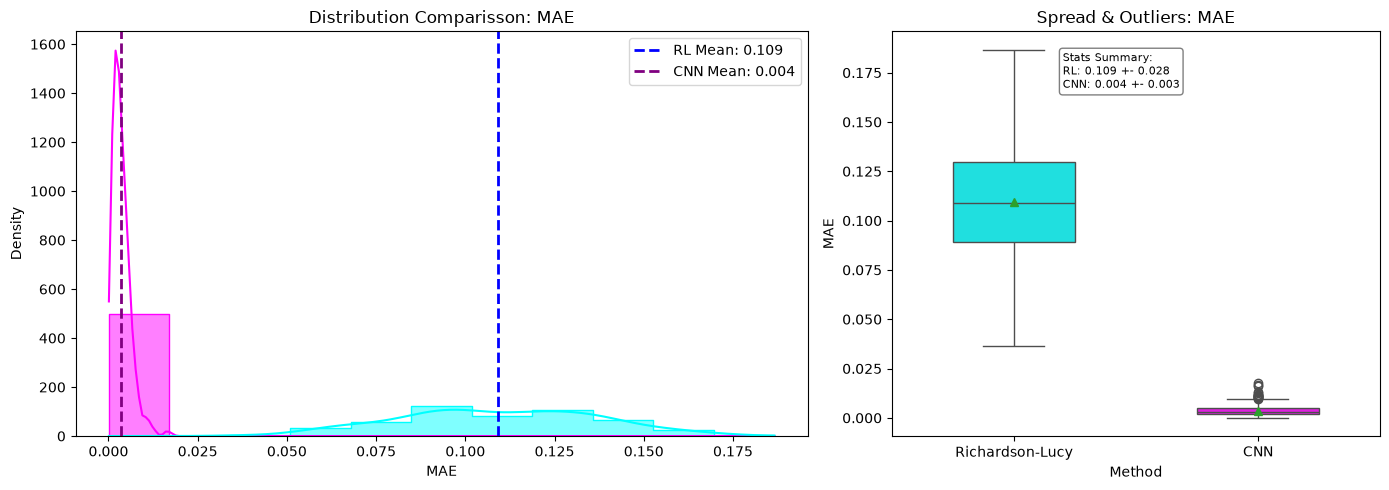

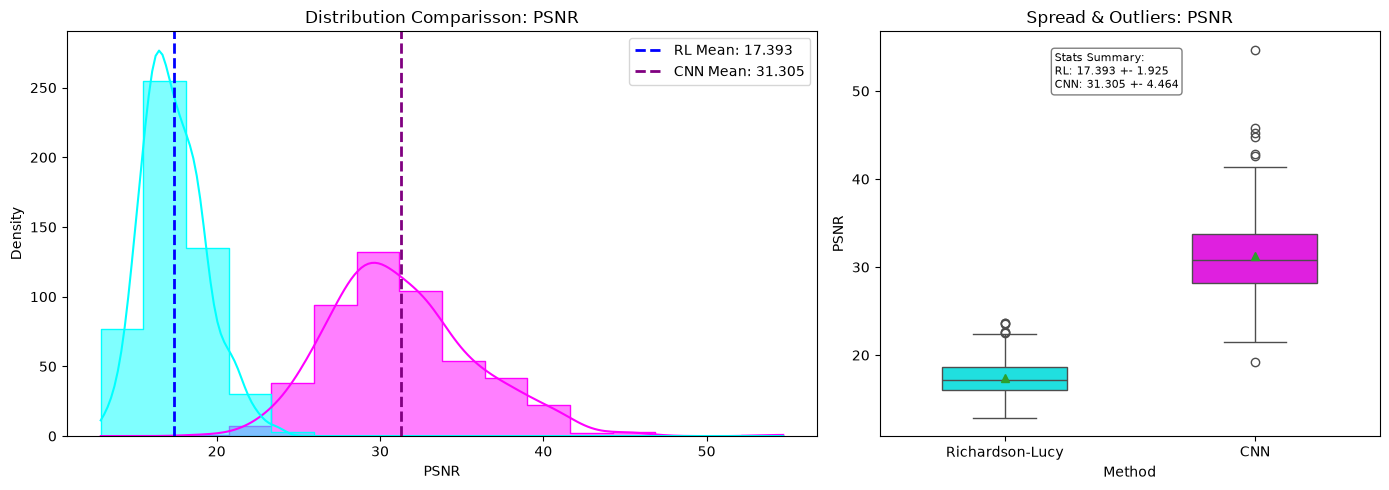

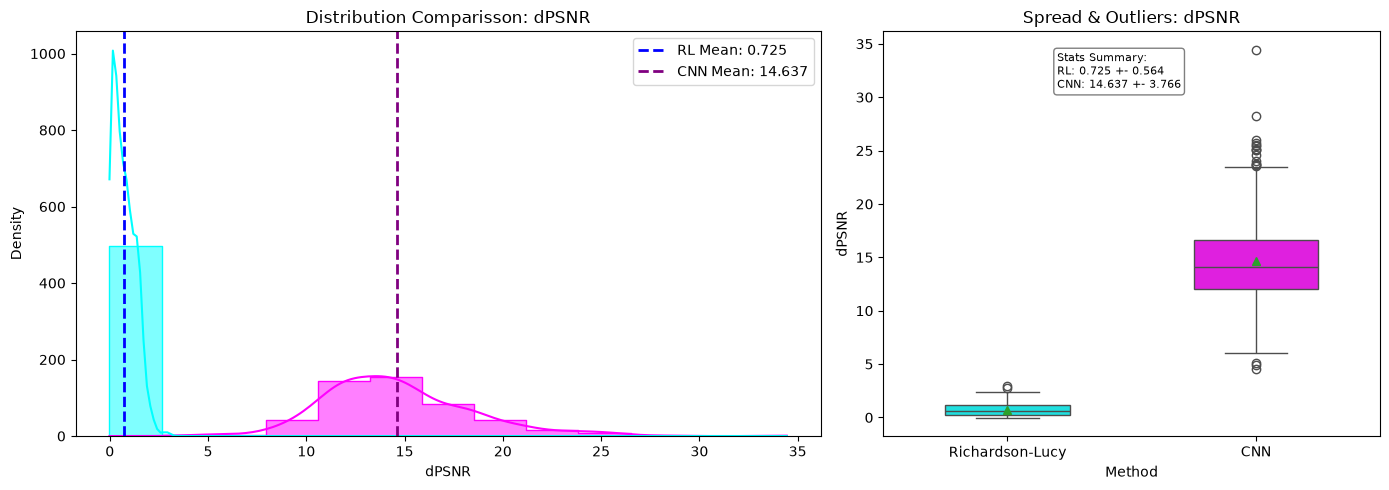

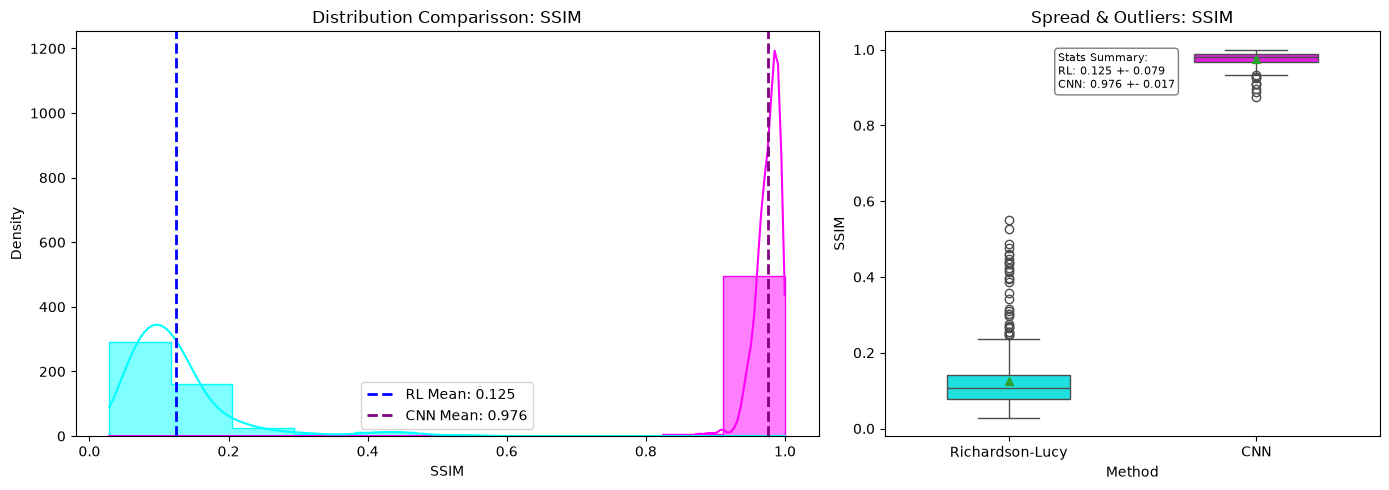

In [4]:
# Create full detector model dataset
# Create blur only dataset
test_dataset_full = GeometricDataGenerator(
    num_samples=500,
    size=256,
    seed=42,
    poisson_noise=True,
    full_detector_model=True,
    data_loading=False
)

test_dataset_full_dataloading = GeometricDataGenerator(
    num_samples=500,
    size=256,
    seed=42,
    poisson_noise=True,
    full_detector_model=True,
    data_loading=True
)
test_dataloader_full = DataLoader(
    test_dataset_full_dataloading,
    batch_size=1
)

df_full = comparative_testing(
    dataset=test_dataset_full,
    dataloader=test_dataloader_full,
    model=model,
    model_about_df=model_about_df,
    device=device,
    path="comparison",
    filename="comparative_results_full.csv"
)
plot_comparative_results(
    df=df_full,
    path="comparison",
    save_name='comparative_results_full'
)